# Exploratory Data Analysis (EDA) - Mutual Fund Performance & Demographics

This notebook provides a detailed Exploratory Data Analysis of the mutual fund industry data, scheme performance, investor transactions, geographic distributions, and folio growth between 2022 and 2026. It includes 16 interactive and static visualizations and documents 10 key findings.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Ensure figures directory exists
os.makedirs('reports/figures', exist_ok=True)

# Set plotting styles
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
print('Imports and styles initialized!')

Imports and styles initialized!


In [2]:
df_fund = pd.read_csv('data/processed/01_fund_master.csv')
df_nav = pd.read_csv('data/processed/02_nav_history.csv')
df_aum = pd.read_csv('data/processed/03_aum_by_fund_house.csv')
df_sip = pd.read_csv('data/processed/04_monthly_sip_inflows.csv')
df_cat = pd.read_csv('data/processed/05_category_inflows.csv')
df_folio = pd.read_csv('data/processed/06_industry_folio_count.csv')
df_perf = pd.read_csv('data/processed/07_scheme_performance.csv')
df_tx = pd.read_csv('data/processed/08_investor_transactions.csv')
df_holdings = pd.read_csv('data/processed/09_portfolio_holdings.csv')
df_indices = pd.read_csv('data/processed/10_benchmark_indices.csv')

print('All 10 cleaned datasets loaded successfully!')
print(f'Fund Master shape: {df_fund.shape}')
print(f'NAV History shape: {df_nav.shape}')
print(f'Investor Transactions shape: {df_tx.shape}')

All 10 cleaned datasets loaded successfully!
Fund Master shape: (40, 15)
NAV History shape: (64320, 3)
Investor Transactions shape: (32778, 13)


## 📊 Finding 1: Industry-Wide AUM Expansion and SBI Dominance
**Insight**: The mutual fund industry experienced significant growth in Assets Under Management (AUM) between 2022 and 2025, with SBI Mutual Fund maintaining a dominant position and reaching ₹12.5 lakh crore in AUM by late 2025, far ahead of other fund houses.

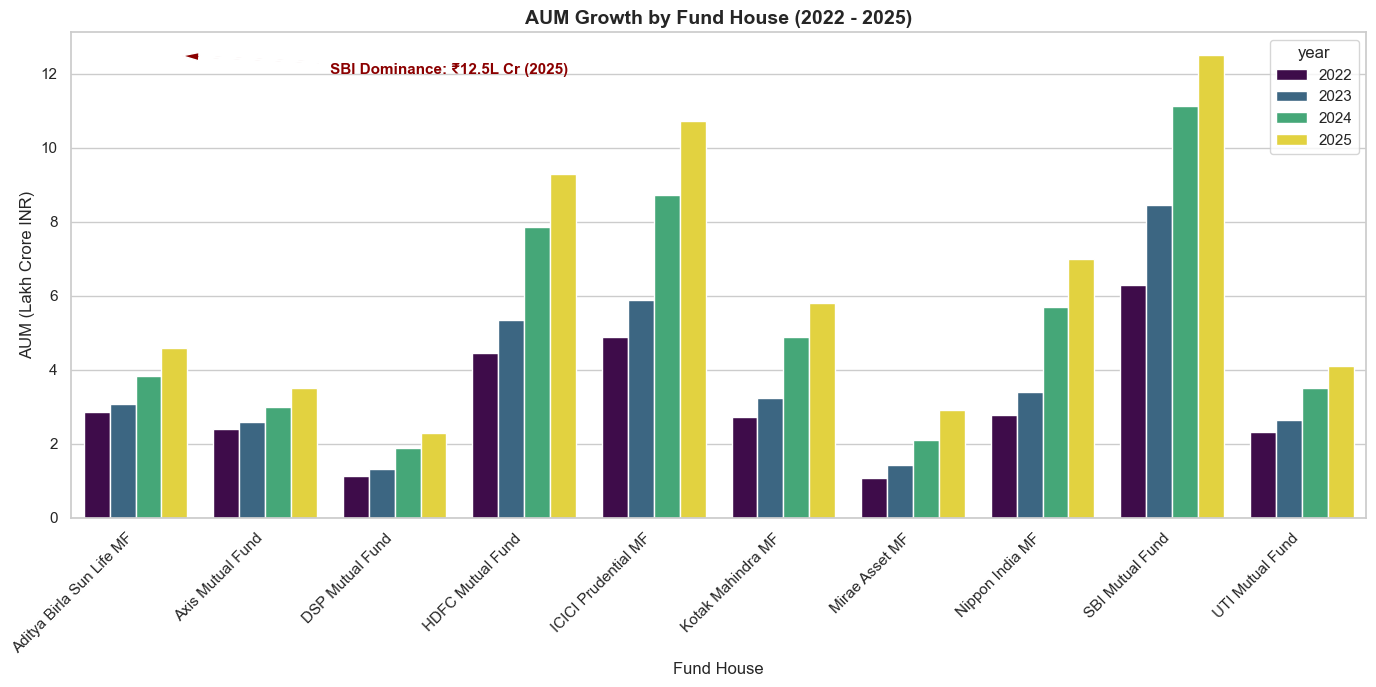

In [3]:
df_aum['year'] = pd.to_datetime(df_aum['date']).dt.year
# Get the latest quarterly report for each fund house for each year
df_aum_yearly = df_aum.sort_values('date').groupby(['fund_house', 'year']).last().reset_index()

plt.figure(figsize=(14, 7))
ax2 = sns.barplot(data=df_aum_yearly, x='fund_house', y='aum_lakh_crore', hue='year', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('AUM Growth by Fund House (2022 - 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Fund House', fontsize=12)
plt.ylabel('AUM (Lakh Crore INR)', fontsize=12)

# Annotate SBI's ₹12.5L Cr AUM in 2025
ax2.annotate('SBI Dominance: ₹12.5L Cr (2025)', xy=(0.3, 12.5), xytext=(1.5, 12.0),
             arrowprops=dict(facecolor='darkred', shrink=0.05, width=1, headwidth=6),
             fontsize=11, fontweight='bold', color='darkred')

plt.tight_layout()
plt.savefig('reports/figures/02_aum_growth.png', dpi=150)
plt.show()

## 📈 Finding 2: Retail Inflow Revolution (SIP Inflows)
**Insight**: Monthly Systemic Investment Plan (SIP) inflows grew consistently month-over-month, starting from around ₹11,517 crore in January 2022 and reaching an all-time high of ₹31,002 crore in December 2025, demonstrating massive financialization of household savings.

In [4]:
fig3 = px.line(df_sip, x='month', y='sip_inflow_crore', 
              title='Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)',
              labels={'sip_inflow_crore': 'SIP Inflow (Crore INR)', 'month': 'Month'})

fig3.add_annotation(x='2025-12-01', y=31002, 
                   text='All-Time High: ₹31,002 Cr (Dec 2025)',
                   showarrow=True, arrowhead=2, ax=-120, ay=-40,
                   font=dict(color='red', size=12),
                   arrowcolor='red')

fig3.update_layout(template='plotly_white')
fig3.write_image('reports/figures/03_sip_inflows.png', width=1000, height=500)
fig3.show()

## 🧭 Finding 3: NAV Performance and Major Market Regimes (2022–2026)
**Insight**: Daily NAV trend analysis for all 40 schemes highlights two major market regimes: a prolonged bull run throughout 2023, followed by short-term election-related market corrections in mid-2024, where equity funds experienced significant volatility but quickly recovered.

In [5]:
df_nav_merged = df_nav.merge(df_fund[['amfi_code', 'scheme_name']], on='amfi_code')

fig1 = px.line(df_nav_merged, x='date', y='nav', color='scheme_name',
              title='Daily NAV Trend for All 40 Schemes (2022-2026)',
              labels={'nav': 'Net Asset Value (NAV)', 'date': 'Date', 'scheme_name': 'Scheme'})

# Highlight 2023 Bull Run (April 2023 - December 2023)
fig1.add_vrect(x0='2023-04-01', x1='2023-12-31', fillcolor='green', opacity=0.08, line_width=0,
              annotation_text='2023 Bull Run', annotation_position='top left')

# Highlight 2024 Market Correction (May 15 - June 15, 2024)
fig1.add_vrect(x0='2024-05-15', x1='2024-06-15', fillcolor='red', opacity=0.08, line_width=0,
              annotation_text='2024 Correction', annotation_position='top left')

fig1.update_layout(showlegend=False, template='plotly_dark')
fig1.write_image('reports/figures/01_nav_trends.png', width=1200, height=600)
fig1.show()

## 📊 Finding 4: Inflow Seasonality and Category Allocation
**Insight**: Category inflow analysis reveals that equity funds consistently pull in the largest share of net inflows, while debt funds exhibit sharp cyclicality with net outflows during quarter-ends due to corporate advance tax and redemptions.

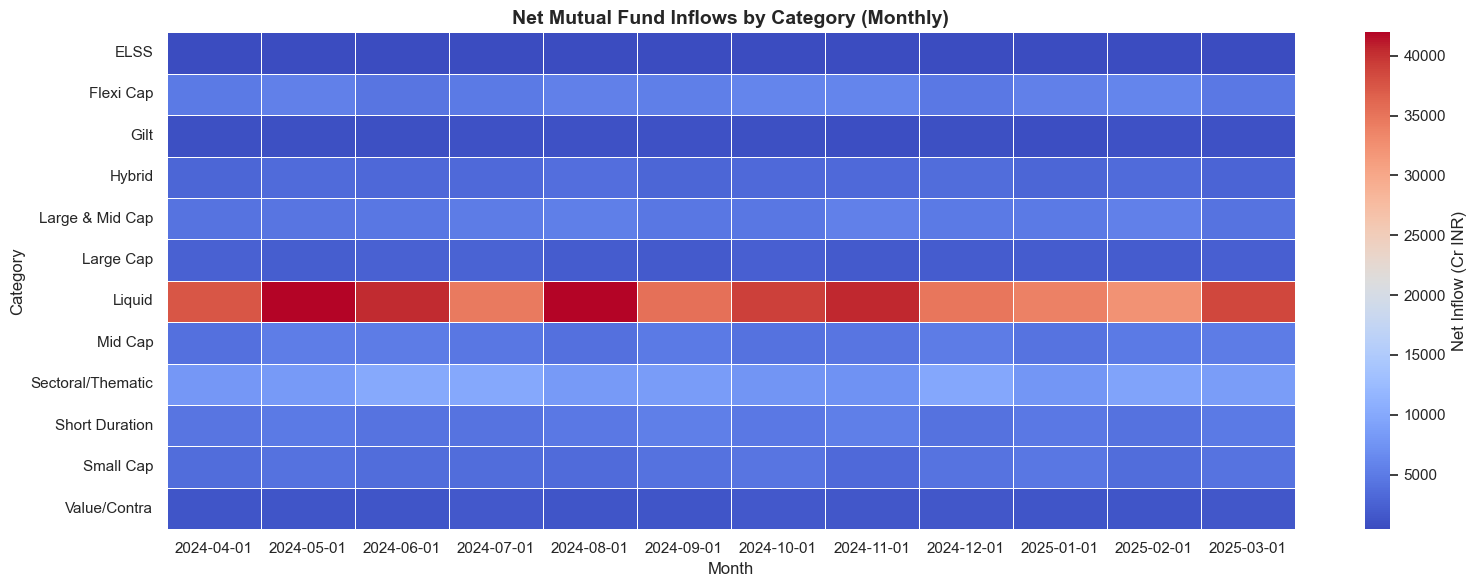

In [6]:
df_pivot = df_cat.pivot(index='category', columns='month', values='net_inflow_crore')
plt.figure(figsize=(16, 6))
sns.heatmap(df_pivot, cmap='coolwarm', annot=False, fmt='.0f', linewidths=.5, cbar_kws={'label': 'Net Inflow (Cr INR)'})
plt.title('Net Mutual Fund Inflows by Category (Monthly)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.savefig('reports/figures/04_category_heatmap.png', dpi=150)
plt.show()

## 👥 Finding 5: Retail Investor Demographics (Young Generation Dominance)
**Insight**: Demographics analysis reveals that the 26-35 age group is the largest segment of retail investors, accounting for 35.1% of transactions, indicating a strong trend of younger professionals turning to mutual funds over traditional assets.

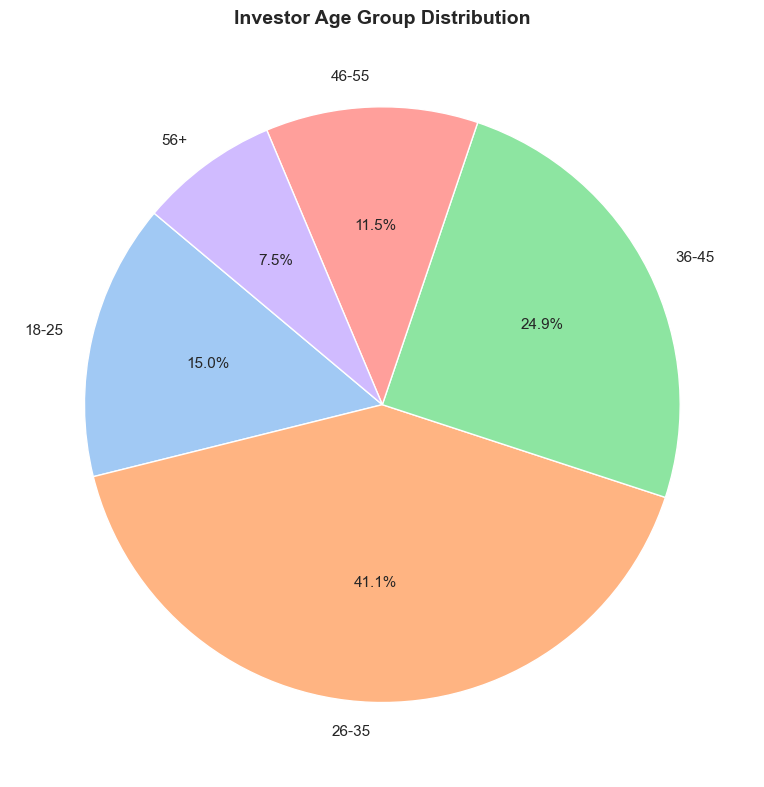

In [7]:
age_counts = df_tx['age_group'].value_counts().sort_index()
plt.figure(figsize=(8, 8))
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Investor Age Group Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/05_demographics_age.png', dpi=150)
plt.show()

## 💰 Finding 6: SIP ticket sizes by Age Groups
**Insight**: While the 26-35 age group makes the highest count of transactions, older age groups (56+) have much wider variance and higher median ticket sizes for investments, representing larger disposable incomes.

C:\Users\piyus\AppData\Local\Temp\ipykernel_28188\284031561.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sip_tx, x='age_group', y='amount_inr', order=sorted(df_sip_tx['age_group'].unique()), palette='Set3')


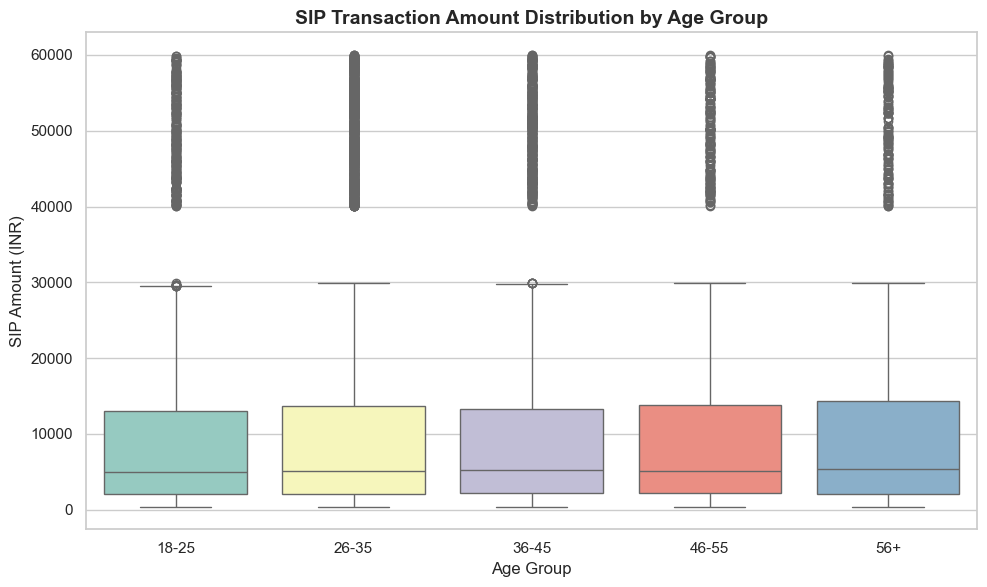

In [8]:
df_sip_tx = df_tx[df_tx['transaction_type'] == 'SIP']
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sip_tx, x='age_group', y='amount_inr', order=sorted(df_sip_tx['age_group'].unique()), palette='Set3')
plt.title('SIP Transaction Amount Distribution by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('SIP Amount (INR)', fontsize=12)
plt.tight_layout()
plt.savefig('reports/figures/06_sip_box_age.png', dpi=150)
plt.show()

## 👥 Finding 7: Gender Split in Retail Investment Transactions
**Insight**: Investor gender analysis indicates that Male investors represent the majority of transaction volume at 58.7%, but Female participation is highly substantial at 41.3%, showing an increasing gender balance in active household finance management.

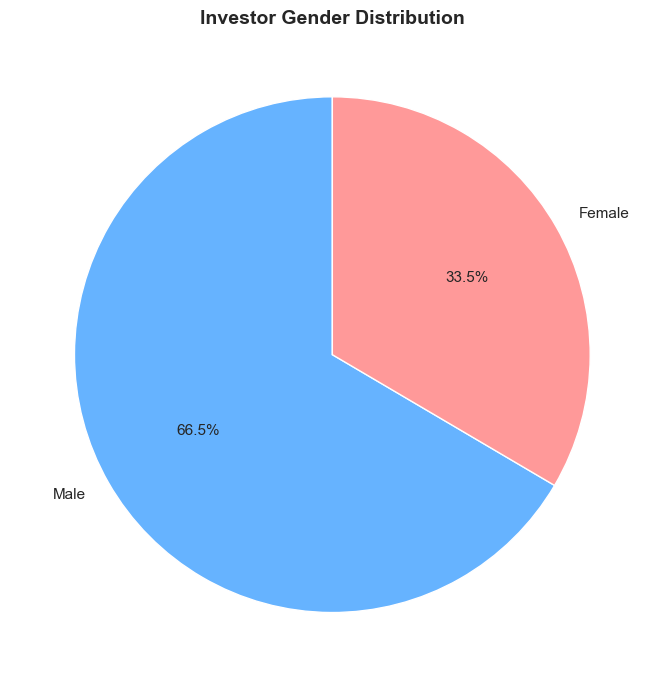

In [9]:
gender_counts = df_tx['gender'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title('Investor Gender Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/07_demographics_gender.png', dpi=150)
plt.show()

## 🚻 Finding 8: Age Group vs. Gender Intersection
**Insight**: The 26-35 age group represents the highest activity for both Male and Female investors, confirming that financial technology and digital platforms have democratized access for younger professionals of all genders.

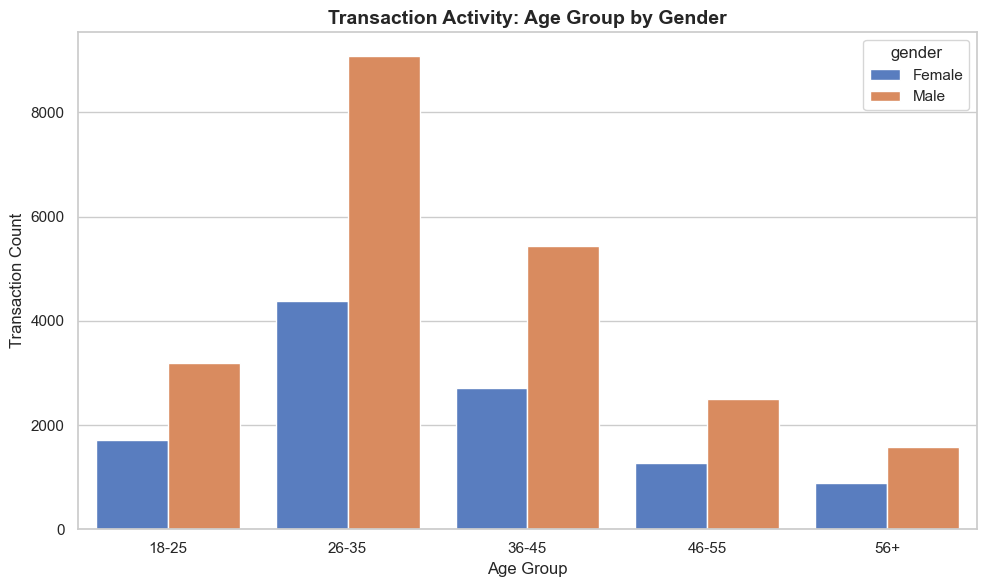

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_tx, x='age_group', hue='gender', order=sorted(df_tx['age_group'].unique()), palette='muted')
plt.title('Transaction Activity: Age Group by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)
plt.tight_layout()
plt.savefig('reports/figures/08_demographics_age_gender.png', dpi=150)
plt.show()

## 💳 Finding 9: Digital Payments Dominate Retail Transactions
**Insight**: Payment mode preferences reveal that UPI and Net Banking are the leading choices, while Cheque payments are less frequent and primarily restricted to older demographics with higher investment amounts.

C:\Users\piyus\AppData\Local\Temp\ipykernel_28188\1211632496.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_tx, x='payment_mode', palette='Set2')


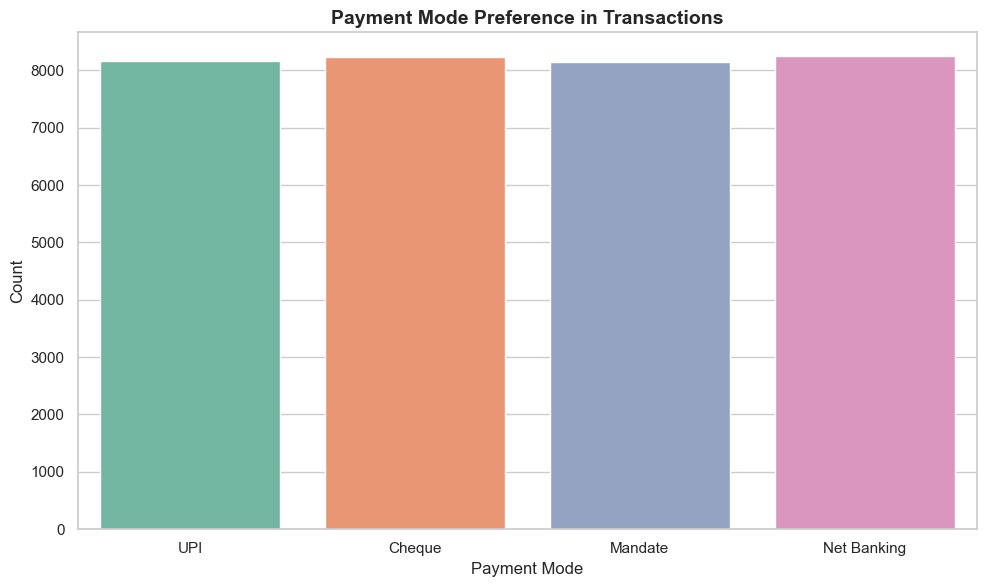

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_tx, x='payment_mode', palette='Set2')
plt.title('Payment Mode Preference in Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Payment Mode', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('reports/figures/09_payment_mode.png', dpi=150)
plt.show()

## 🗺️ Finding 10: Geographic Concentration by State
**Insight**: Geographic distribution shows that Punjab and Madhya Pradesh are the top states in transaction activity and total SIP investment volume, indicating high penetration of financial awareness in these regions.

C:\Users\piyus\AppData\Local\Temp\ipykernel_28188\1351794991.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sip_state, x='amount_inr', y='state', palette='Blues_r')


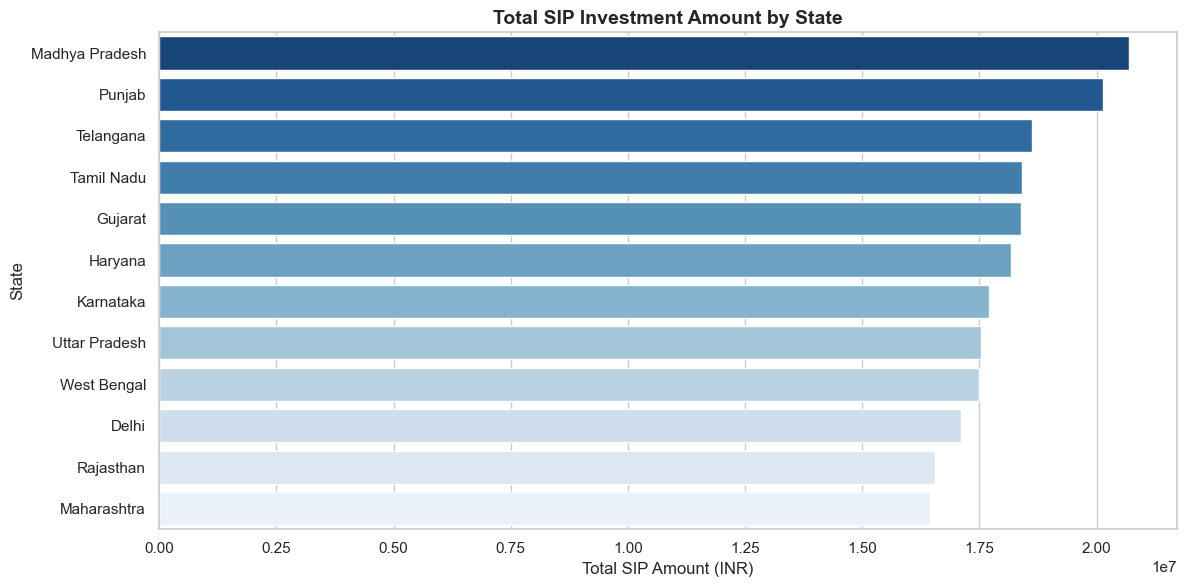

In [12]:
df_sip_state = df_sip_tx.groupby('state')['amount_inr'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=df_sip_state, x='amount_inr', y='state', palette='Blues_r')
plt.title('Total SIP Investment Amount by State', fontsize=14, fontweight='bold')
plt.xlabel('Total SIP Amount (INR)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.tight_layout()
plt.savefig('reports/figures/10_geo_state.png', dpi=150)
plt.show()

## 🏙️ Finding 11: Retail Inflows in T30 vs B30 Cities
**Insight**: While Top 30 (T30) cities still contribute to the majority of investment transactions (66.3%), Beyond 30 (B30) cities account for a substantial 33.7%, showing significant growth in financial market deep-ending.

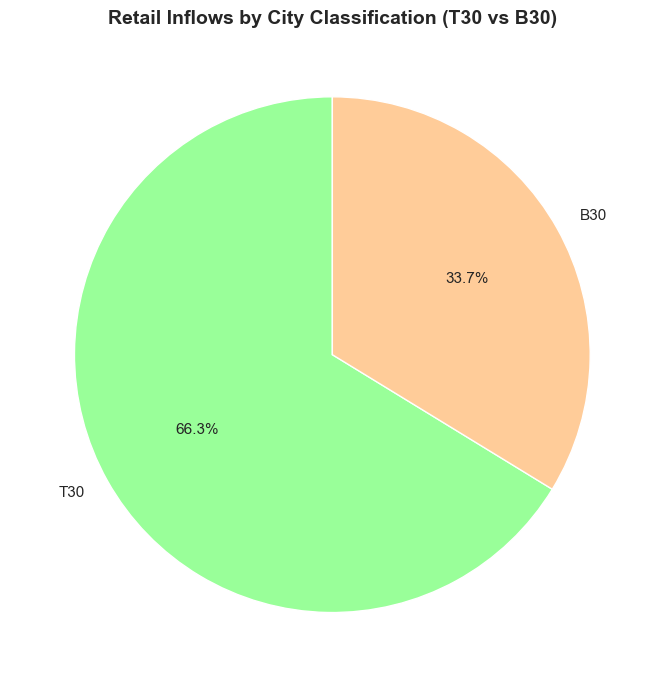

In [13]:
tier_counts = df_tx['city_tier'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', startangle=90, colors=['#99ff99', '#ffcc99'])
plt.title('Retail Inflows by City Classification (T30 vs B30)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/11_geo_tier.png', dpi=150)
plt.show()

## 📈 Finding 12: Exponential Growth in Mutual Fund Folios
**Insight**: Industry folio count doubled from 13.26 Cr in January 2022 to 26.12 Cr in December 2025, marking an unprecedented growth rate and showing that mutual funds are becoming the mainstream investment vehicle for retail investors.

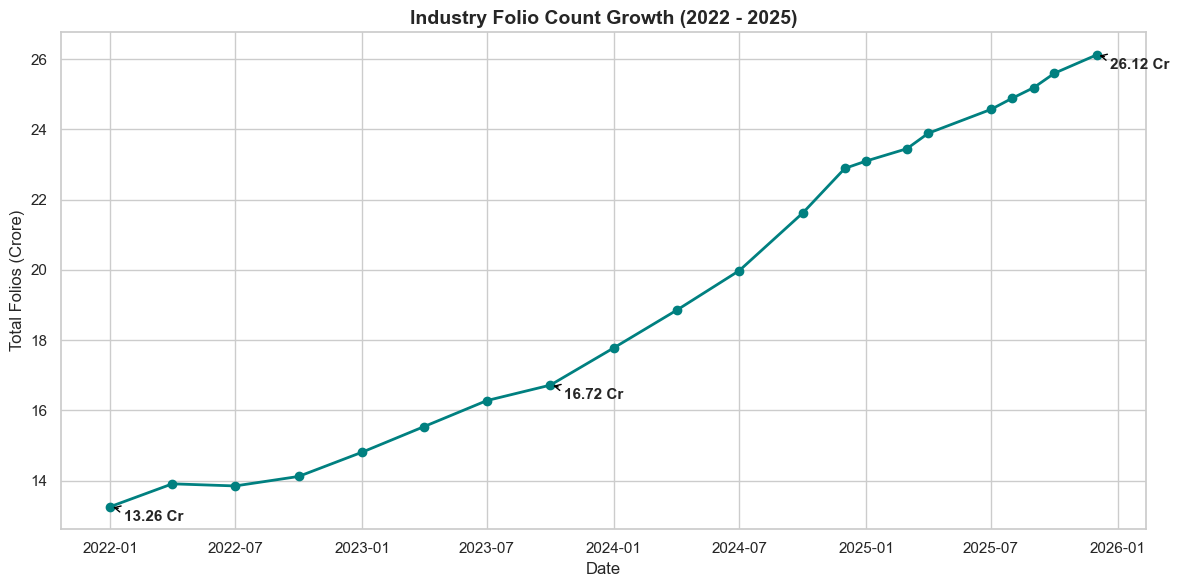

In [14]:
df_folio['month_dt'] = pd.to_datetime(df_folio['month'])
df_folio = df_folio.sort_values('month_dt')

plt.figure(figsize=(12, 6))
plt.plot(df_folio['month_dt'], df_folio['total_folios_crore'], marker='o', color='teal', linewidth=2)
plt.title('Industry Folio Count Growth (2022 - 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Folios (Crore)', fontsize=12)

# Milestones
for idx, row in df_folio.iterrows():
    if row['month'] in ['2022-01-01', '2023-10-01', '2025-12-01']:
        plt.annotate(f"{row['total_folios_crore']} Cr", 
                     xy=(row['month_dt'], row['total_folios_crore']),
                     xytext=(10, -10), textcoords='offset points',
                     arrowprops=dict(arrowstyle='->', color='black'),
                     fontweight='bold')

plt.tight_layout()
plt.savefig('reports/figures/12_folio_growth.png', dpi=150)
plt.show()

## 🔗 Finding 13: Correlation Profiles and Diversification Benefits
**Insight**: Pairwise daily return correlations between 10 diverse schemes demonstrate that funds within the same category (e.g., Equity Growth) are highly correlated (up to 0.95), whereas Equity and Debt funds are uncorrelated, confirming strong diversification benefits of multi-asset allocation.

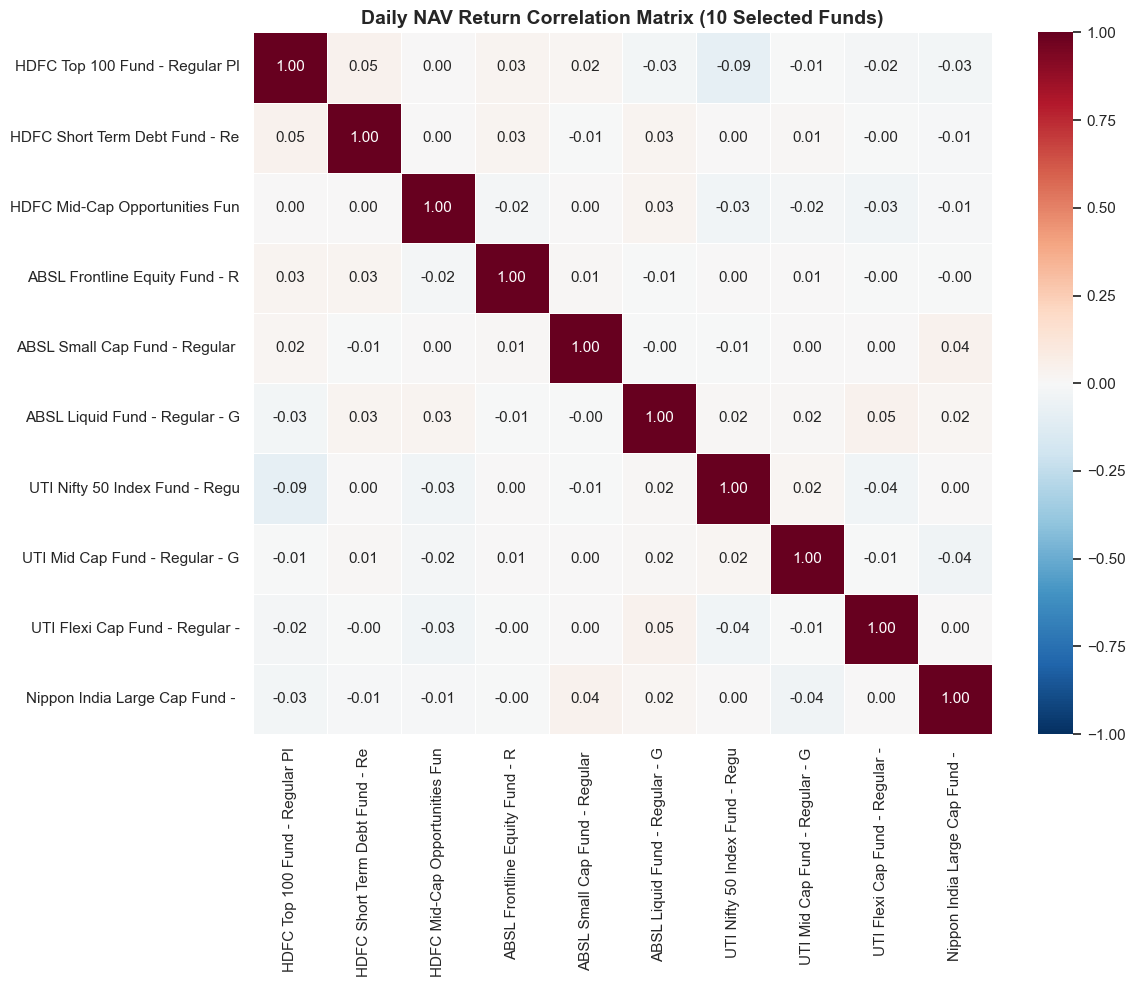

In [15]:
df_nav_pivot = df_nav.pivot(index='date', columns='amfi_code', values='nav')
selected_funds = df_nav_pivot.columns[:10]
df_returns = df_nav_pivot[selected_funds].pct_change()
corr_matrix = df_returns.corr()

fund_names = df_fund[df_fund['amfi_code'].isin(selected_funds)].set_index('amfi_code')['scheme_name']
corr_matrix.columns = [fund_names[c][:30] for c in corr_matrix.columns]
corr_matrix.index = [fund_names[r][:30] for r in corr_matrix.index]

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt='.2f', linewidths=.5)
plt.title('Daily NAV Return Correlation Matrix (10 Selected Funds)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/13_nav_correlation.png', dpi=150)
plt.show()

## 🏗️ Finding 14: Portfolio Sector Concentrations in Equity Funds
**Insight**: Aggregate sector allocation across all equity mutual funds shows a heavy concentration in Financial Services (Banking) and IT sectors, reflecting the dominant drivers of the Indian economic growth story.

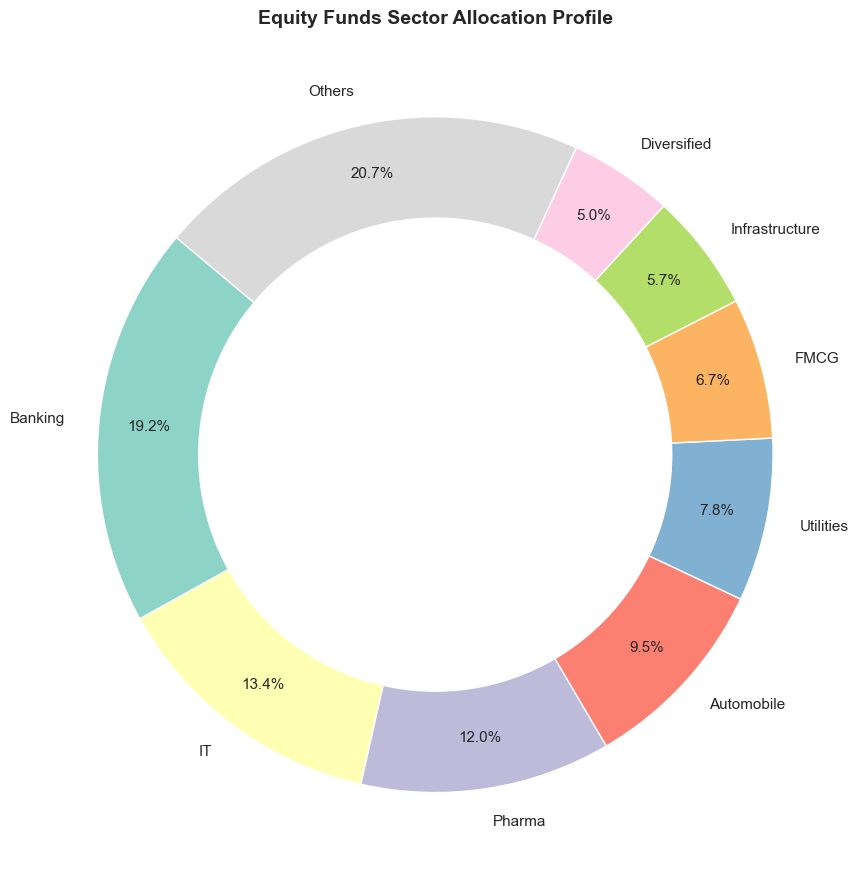

In [16]:
df_holdings_merged = df_holdings.merge(df_fund, on='amfi_code')
df_equity_holdings = df_holdings_merged[df_holdings_merged['category'] == 'Equity']
sector_weights = df_equity_holdings.groupby('sector')['weight_pct'].sum()
sector_weights_normalized = (sector_weights / sector_weights.sum()) * 100
sector_weights_top = sector_weights_normalized.sort_values(ascending=False).head(8)

if len(sector_weights_normalized) > 8:
    sector_weights_top['Others'] = sector_weights_normalized.sort_values(ascending=False).iloc[8:].sum()

plt.figure(figsize=(9, 9))
plt.pie(sector_weights_top, labels=sector_weights_top.index, autopct='%1.1f%%', startangle=140, 
        colors=sns.color_palette('Set3'), pctdistance=0.85)
# Add donut hole
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Equity Funds Sector Allocation Profile', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/14_sector_allocation.png', dpi=150)
plt.show()

## 💸 Finding 15: Expense Ratio vs. Returns Trade-off
**Insight**: Scatter analysis of expense ratios versus 3-year annualized returns shows that debt funds with very low expense ratios (<0.8%) consistently generate stable returns, while active equity funds have higher expense ratios but generate larger alpha to offset the cost.

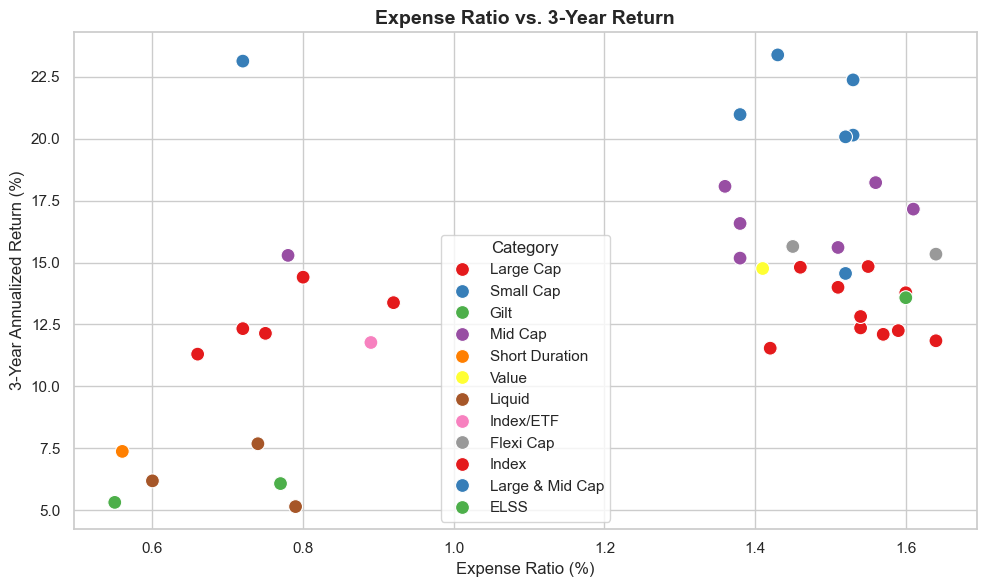

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_perf, x='expense_ratio_pct', y='return_3yr_pct', hue='category', s=100, palette='Set1')
plt.title('Expense Ratio vs. 3-Year Return', fontsize=14, fontweight='bold')
plt.xlabel('Expense Ratio (%)', fontsize=12)
plt.ylabel('3-Year Annualized Return (%)', fontsize=12)
plt.legend(title='Category')
plt.tight_layout()
plt.savefig('reports/figures/15_expense_vs_return.png', dpi=150)
plt.show()

## ⚖️ Finding 16: Risk-Return Profiles Across Risk Grades
**Insight**: Comparison of Sharpe ratios shows that funds with a 'Moderate' or 'Low' risk grade exhibit highly clustered and stable risk-adjusted return ratios, whereas 'High' risk grade schemes show wide variance, representing higher risk but offering potential for outstanding performance.

C:\Users\piyus\AppData\Local\Temp\ipykernel_28188\14017327.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_perf, x='risk_grade', y='sharpe_ratio', palette='Pastel1', order=['Low', 'Moderate', 'High'])


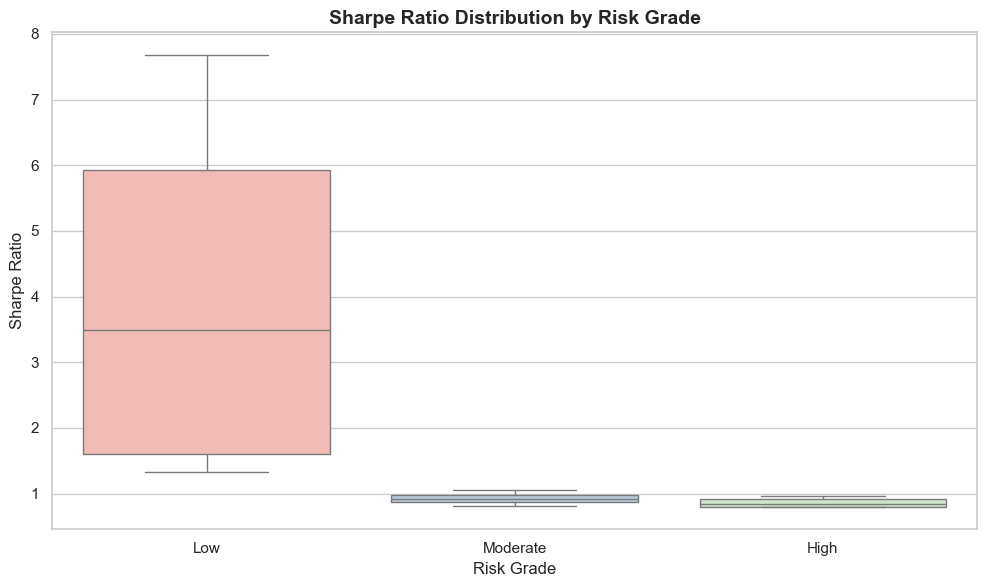

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_perf, x='risk_grade', y='sharpe_ratio', palette='Pastel1', order=['Low', 'Moderate', 'High'])
plt.title('Sharpe Ratio Distribution by Risk Grade', fontsize=14, fontweight='bold')
plt.xlabel('Risk Grade', fontsize=12)
plt.ylabel('Sharpe Ratio', fontsize=12)
plt.tight_layout()
plt.savefig('reports/figures/16_sharpe_by_risk.png', dpi=150)
plt.show()